# PW02 - KNN for Supervised Classification and Regression

**Team:** Noé Berdoz, Michael Strefeler

## Preamble: our starting level

- **Noé Berdoz**: Bachelor in Business Information Technology (Informatique de gestion) at HE-Arc, completed in 2026. Background in software development, with little prior experience in machine learning before this course.
- **Michael Strefeler**: Bachelor in Computer and Communication Systems (ISC) at HEIG-VD, completed in 2025, with a specialisation in data science, so he had already seen some machine learning before this course.

We worked hard on this PW, sometimes until late in the evening. It taught us a lot, especially Noé, for whom most of these notions were new, and it refreshed several notions for Michael. We hope it can earn us a bonus point.

In [1]:
# Same setup code as exercise 3

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# This is a bit of magic to make matplotlib figures appear inline in the notebook
# rather than in a new window. Also setting some parameters for display.
%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 10.0)  # set default size of plots
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

In [ ]:
# Simplified version of KNearestNeighbor class from exercice 3
class KNearestNeighbor(object):
    """a kNN classifier with L2 distance"""

    def __init__(self):
        pass

    def train(self, X, y):
        """
        Train the classifier. For k-nearest neighbors this is just
        memorizing the training data.

        Inputs:
        - X: A numpy array of shape (num_train, D) containing the training data
          consisting of num_train samples each of dimension D.
        - y: A numpy array of shape (N,) containing the training labels, where
             y[i] is the label for X[i].
        """
        self.X_train = X
        self.y_train = y

    def predict(self, X, k=1, num_loops=0):
        """
        Predict labels for test data using this classifier.

        Inputs:
        - X: A numpy array of shape (num_test, D) containing test data consisting
             of num_test samples each of dimension D.
        - k: The number of nearest neighbors that vote for the predicted labels.
        - num_loops: Determines which implementation to use to compute distances
          between training points and testing points.

        Returns:
        - y: A numpy array of shape (num_test,) containing predicted labels for the
          test data, where y[i] is the predicted label for the test point X[i].
        """

        dists = self.compute_distances_no_loops(X)

        return self.predict_labels(dists, k=k)

    def compute_distances_no_loops(self, X):
        """
                Compute the distance between each test point in X and each training point
                in self.X_train using no explicit loops.

                Inputs:
                    - X: A numpy array of shape (num_test, D) containing test data.

        , Returns:
        , - dists: A numpy array of shape (num_test, num_train) where dists[i, j]
                      is the Euclidean distance between the ith test point and the jth training
                      point.
        """
        num_test = X.shape[0]
        num_train = self.X_train.shape[0]
        dists = np.zeros((num_test, num_train))

        test_sq = np.sum(X**2, axis=1).reshape(num_test, 1)  # (num_test, 1)
        train_sq = np.sum(self.X_train**2, axis=1).reshape(
            1, num_train
        )  # (1, num_train)
        cross_term = X.dot(self.X_train.T)  # (num_test, num_train)
        dists = np.sqrt(test_sq - 2 * cross_term + train_sq)

        return dists

    def predict_labels(self, dists, k=1):
        """
        Given a matrix of distances between test points and training points,
        predict a label for each test point.

        Inputs:
        - dists: A numpy array of shape (num_test, num_train) where dists[i, j]
          gives the distance betwen the ith test point and the jth training point.

        Returns:
        - y: A numpy array of shape (num_test,) containing predicted labels for the
          test data, where y[i] is the predicted label for the test point X[i].
        """
        num_test = dists.shape[0]
        y_pred = np.zeros(num_test)
        for i in range(num_test):
            # A list of length k storing the labels of the k nearest neighbors to
            # the ith test point.
            closest_y = []

            closest_idx = np.argsort(dists[i])[:k]
            closest_y = self.y_train[closest_idx]
            counts = np.bincount(closest_y)

            y_pred[i] = np.argmax(counts)

        return y_pred

## KNN classification for Fashion MNIST 

Fashion MNIST is a dataset from Zalando consisting of a training set of 60000 examples and a test set of 10000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.

The classes are T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot.

They created the dataset because they thought that (digit) MNIST was too easy for current ML models, and it is overused in their opinions.

In [3]:
# MNIST Reader from https://github.com/zalandoresearch/fashion-mnist/blob/master/utils/mnist_reader.py
def load_mnist(path, kind="train"):
    import os
    import gzip
    import numpy as np

    """Load MNIST data from `path`"""
    labels_path = os.path.join(path, "%s-labels-idx1-ubyte.gz" % kind)
    images_path = os.path.join(path, "%s-images-idx3-ubyte.gz" % kind)

    with gzip.open(labels_path, "rb") as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8, offset=8)

    with gzip.open(images_path, "rb") as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8, offset=16).reshape(
            len(labels), 784
        )

    return images, labels

In [4]:
X_train, y_train = load_mnist("data/fashion", kind="train")
X_test, y_test = load_mnist("data/fashion", kind="t10k")

In [5]:
# As a sanity check, we print out the size of the training and test data.
print("Training data shape: ", X_train.shape)
print("Training labels shape: ", y_train.shape)
print("Test data shape: ", X_test.shape)
print("Test labels shape: ", y_test.shape)

Training data shape:  (60000, 784)
Training labels shape:  (60000,)
Test data shape:  (10000, 784)
Test labels shape:  (10000,)


The images are already flattened so we won't need to reshape the arrays with NumPy.

In [6]:
# Subsample the data for more efficient code execution in this exercise. We do this to make it go faster.
# When you will have completed the whole notebook, you can run it again on a larger (or total) dataset
# and observe the difference in terms of accuracy (and speedup).
num_training = 5000
mask = range(num_training)
X_train = X_train[mask].astype(np.float64)
y_train = y_train[mask]

num_test = 500
mask = range(num_test)
X_test = X_test[mask].astype(np.float64)
y_test = y_test[mask]

# sanity check: print out the size of the subsampled training and test data.
print("Training data shape: ", X_train.shape)
print("Training labels shape: ", y_train.shape)
print("Test data shape: ", X_test.shape)
print("Test labels shape: ", y_test.shape)

Training data shape:  (5000, 784)
Training labels shape:  (5000,)
Test data shape:  (500, 784)
Test labels shape:  (500,)


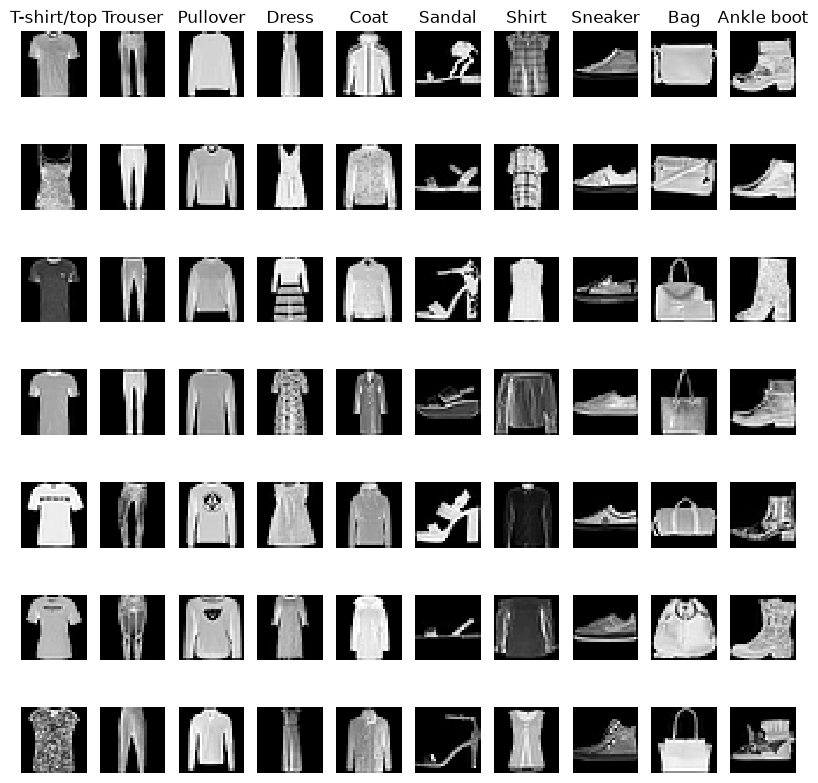

In [7]:
# Now let's visualise some of the images
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):  # y and cls takes values from 0-9
    idxs = np.flatnonzero(
        y_train == y
    )  # gets the indices of samples that corresponds to class y
    idxs = np.random.choice(
        idxs, samples_per_class, replace=False
    )  # picks randomly samples_per_class indices
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1  # determines the sub-plot index
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].reshape(28, 28).astype("uint8"), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.title(cls)
plt.show()

In [8]:
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

In [9]:
dists = classifier.compute_distances_no_loops(X_test)
print(dists.shape)

(500, 5000)


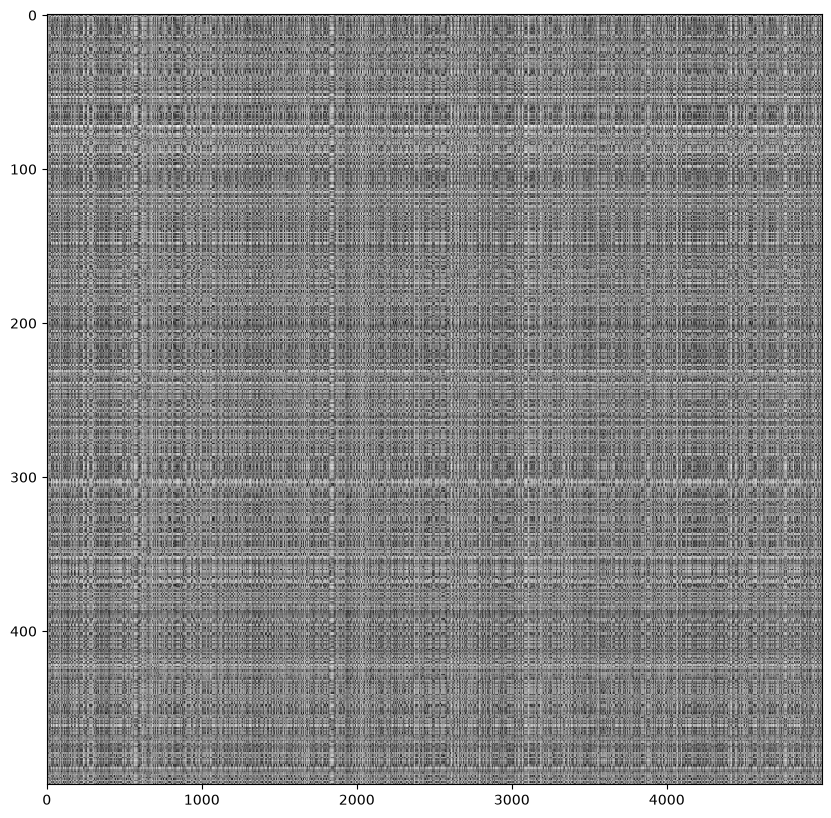

In [10]:
# We can visualize the distance matrix: each row is a single test example and
# its distances to training examples
plt.imshow(dists, interpolation="none", aspect="auto")
plt.show()

In [11]:
y_test_pred = classifier.predict_labels(dists, k=1)

# Compute and print the fraction of correctly predicted examples
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print("Got %d / %d correct => accuracy: %f" % (int(num_correct), num_test, accuracy))

Got 407 / 500 correct => accuracy: 0.814000


### Cross-validation

In [12]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50]

X_train_folds = []
y_train_folds = []

X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

# A dictionary holding the accuracies for different values of k that we find
# when running cross-validation. After running cross-validation,
# k_to_accuracies[k] should be a list of length num_folds giving the different
# accuracy values that we found when using that value of k.
k_to_accuracies = {}

for k in k_choices:
    k_to_accuracies[k] = []
    for f in range(num_folds):
        # Build training data: all folds except fold f
        X_train_cv = np.concatenate(X_train_folds[:f] + X_train_folds[f + 1 :])
        y_train_cv = np.concatenate(y_train_folds[:f] + y_train_folds[f + 1 :])

        # Validation data: fold f
        X_valid_cv = X_train_folds[f]
        y_valid_cv = y_train_folds[f]

        # Train a fresh classifier on the 4 folds
        classifier_cv = KNearestNeighbor()
        classifier_cv.train(X_train_cv, y_train_cv)

        # Predict on the held-out fold
        dists_cv = classifier_cv.compute_distances_no_loops(X_valid_cv)
        y_valid_pred = classifier_cv.predict_labels(dists_cv, k=k)

        num_correct = np.sum(y_valid_pred == y_valid_cv)
        accuracy = float(num_correct) / X_valid_cv.shape[0]
        k_to_accuracies[k].append(accuracy)

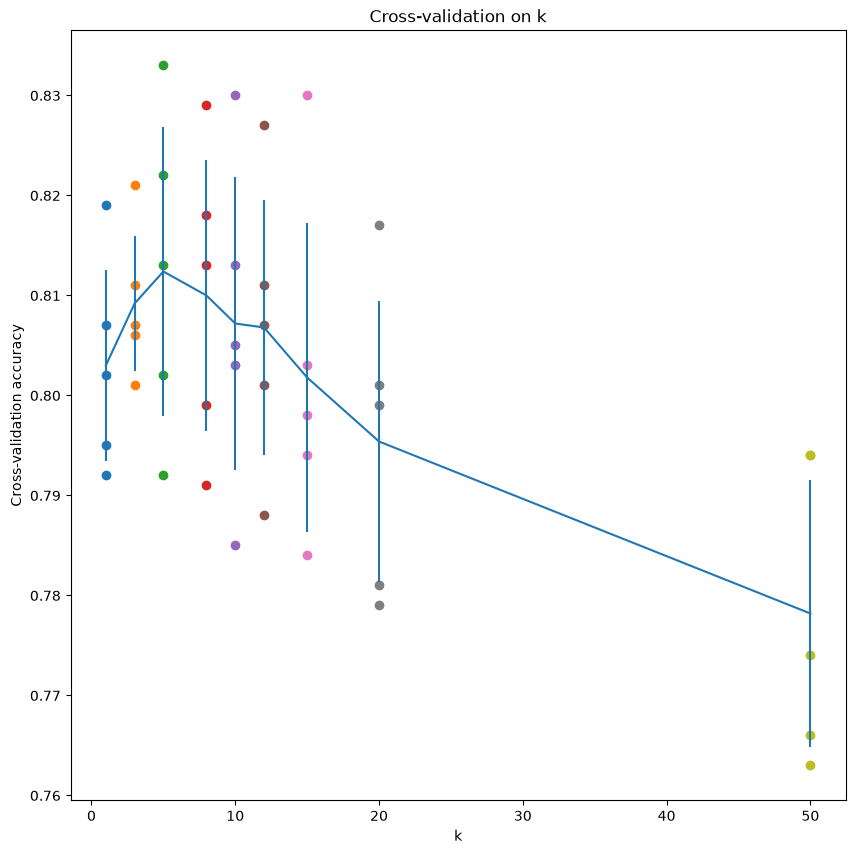

In [13]:
# plot the raw observations
for k in k_choices:
    accuracies = k_to_accuracies[k]
    plt.scatter([k] * len(accuracies), accuracies)

# plot the trend line with error bars that correspond to standard deviation
accuracies_mean = np.array([np.mean(v) for k, v in sorted(k_to_accuracies.items())])
accuracies_std = np.array([np.std(v) for k, v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.title("Cross-validation on k")
plt.xlabel("k")
plt.ylabel("Cross-validation accuracy")
plt.show()

Below you will find the best result of our classifier using the best k found from cross-validation

In [14]:
best_k = 5

# Use entire dataset instead of sub sampling
X_train, y_train = load_mnist("data/fashion", kind="train")
X_test, y_test = load_mnist("data/fashion", kind="t10k")

X_train = X_train.astype(np.float64)
X_test = X_test.astype(np.float64)

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

# Compute and display the accuracy
num_correct = np.sum(y_test_pred == y_test)
num_test = X_test.shape[0]
accuracy = float(num_correct) / num_test
print("Got %d / %d correct => accuracy: %f" % (int(num_correct), num_test, accuracy))

Got 8554 / 10000 correct => accuracy: 0.855400


### Comparison to digit MNIST

Our best performing classifier got an accuracy of 85.54% on the Fashion MNIST dataset vs 97.05% on the digit MNIST dataset. The decrease in performance was to be expected due to the fact that the Fashion MNIST dataset has more complex images with higher "intra" and "inter" class variability.

## KKN Classification with CIFAR10

The CIFAR-10 dataset consists of 60000 32x32 color images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. The classes are airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

In [ ]:
import numpy as np
import pickle
import os


def load_cifar_batch(filename):
    with open(filename, "rb") as f:
        batch = pickle.load(f, encoding="bytes")
    X = batch[b"data"]  # shape (10000, 3072), uint8
    y = np.array(batch[b"labels"])
    return X, y


def load_cifar10(root):
    xs, ys = [], []
    for b in range(1, 6):
        X, y = load_cifar_batch(os.path.join(root, "data_batch_%d" % b))
        xs.append(X)
        ys.append(y)
    X_train = np.concatenate(xs)
    y_train = np.concatenate(ys)
    X_test, y_test = load_cifar_batch(os.path.join(root, "test_batch"))
    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = load_cifar10("data/cifar10/cifar-10-batches-py")

print("Training data shape: ", X_train.shape)
print("Training labels shape: ", y_train.shape)
print("Test data shape: ", X_test.shape)
print("Test labels shape: ", y_test.shape)

Training data shape:  (50000, 3072)
Training labels shape:  (50000,)
Test data shape:  (10000, 3072)
Test labels shape:  (10000,)


The shape of each image is width x height x channels. In this case it's 3072 because we have 32x32 images in color 3 channels (R,G, B).

In [16]:
num_training = 5000
X_train = X_train[:num_training].astype(np.float64)
y_train = y_train[:num_training]

num_test = 500
X_test = X_test[:num_test].astype(np.float64)
y_test = y_test[:num_test]

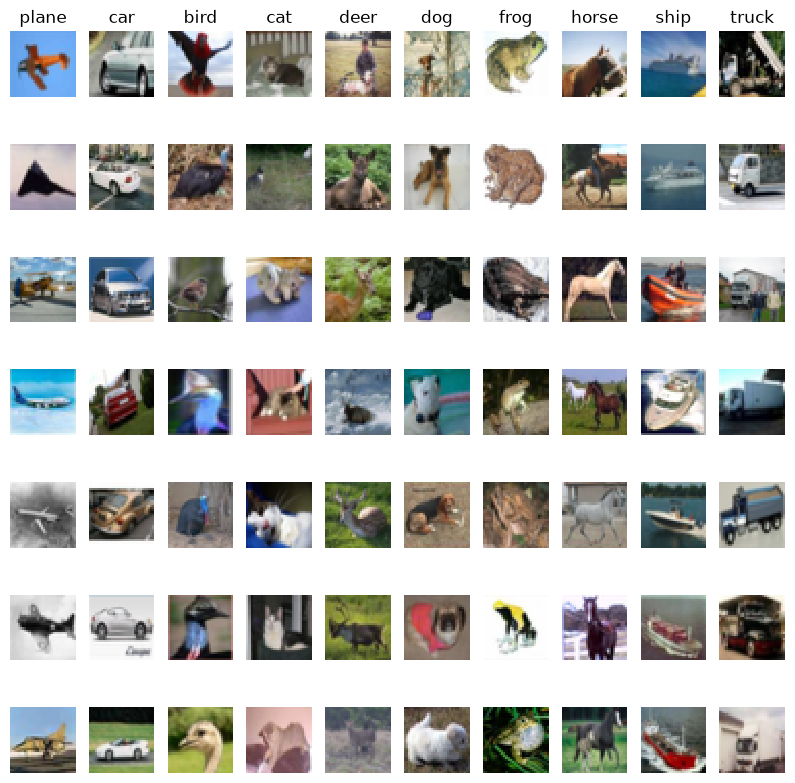

In [17]:
classes = ["plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].reshape(3, 32, 32).transpose(1, 2, 0).astype("uint8"))
        plt.axis("off")
        if i == 0:
            plt.title(cls)
plt.show()

In [18]:
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

In [19]:
dists = classifier.compute_distances_no_loops(X_test)
print(dists.shape)

(500, 5000)


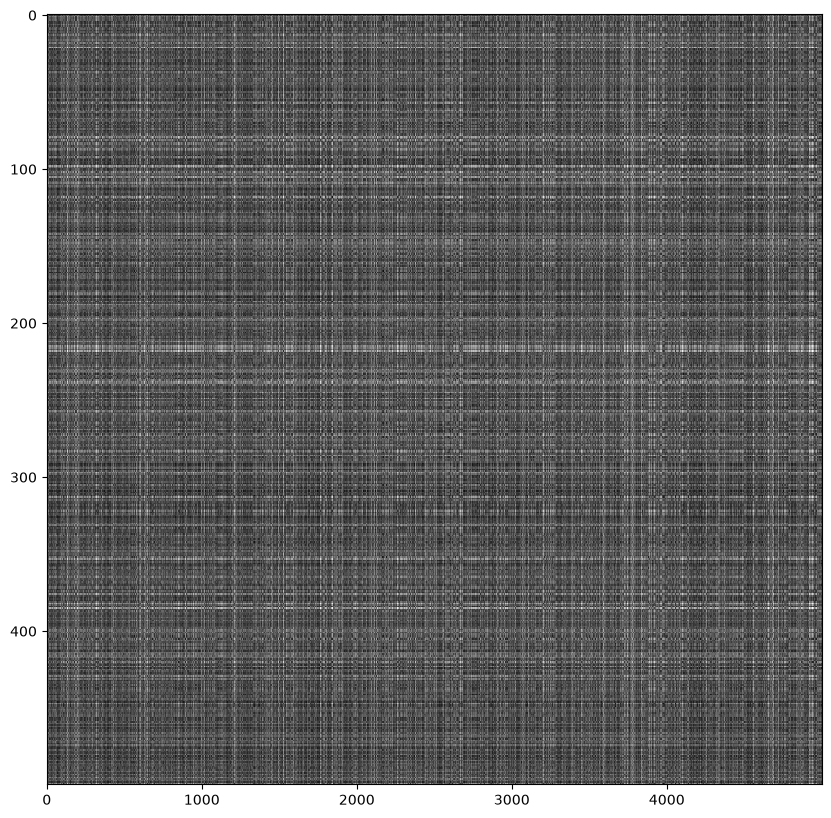

In [20]:
# We can visualize the distance matrix: each row is a single test example and
# its distances to training examples
plt.imshow(dists, interpolation="none", aspect="auto")
plt.show()

In [21]:
y_test_pred = classifier.predict_labels(dists, k=1)

# Compute and print the fraction of correctly predicted examples
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print("Got %d / %d correct => accuracy: %f" % (int(num_correct), num_test, accuracy))

Got 137 / 500 correct => accuracy: 0.274000


### Cross-validation

In [22]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50]

X_train_folds = []
y_train_folds = []

X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

# A dictionary holding the accuracies for different values of k that we find
# when running cross-validation. After running cross-validation,
# k_to_accuracies[k] should be a list of length num_folds giving the different
# accuracy values that we found when using that value of k.
k_to_accuracies = {}

for k in k_choices:
    k_to_accuracies[k] = []
    for f in range(num_folds):
        # Build training data: all folds except fold f
        X_train_cv = np.concatenate(X_train_folds[:f] + X_train_folds[f + 1 :])
        y_train_cv = np.concatenate(y_train_folds[:f] + y_train_folds[f + 1 :])

        # Validation data: fold f
        X_valid_cv = X_train_folds[f]
        y_valid_cv = y_train_folds[f]

        # Train a fresh classifier on the 4 folds
        classifier_cv = KNearestNeighbor()
        classifier_cv.train(X_train_cv, y_train_cv)

        # Predict on the held-out fold
        dists_cv = classifier_cv.compute_distances_no_loops(X_valid_cv)
        y_valid_pred = classifier_cv.predict_labels(dists_cv, k=k)

        num_correct = np.sum(y_valid_pred == y_valid_cv)
        accuracy = float(num_correct) / X_valid_cv.shape[0]
        k_to_accuracies[k].append(accuracy)

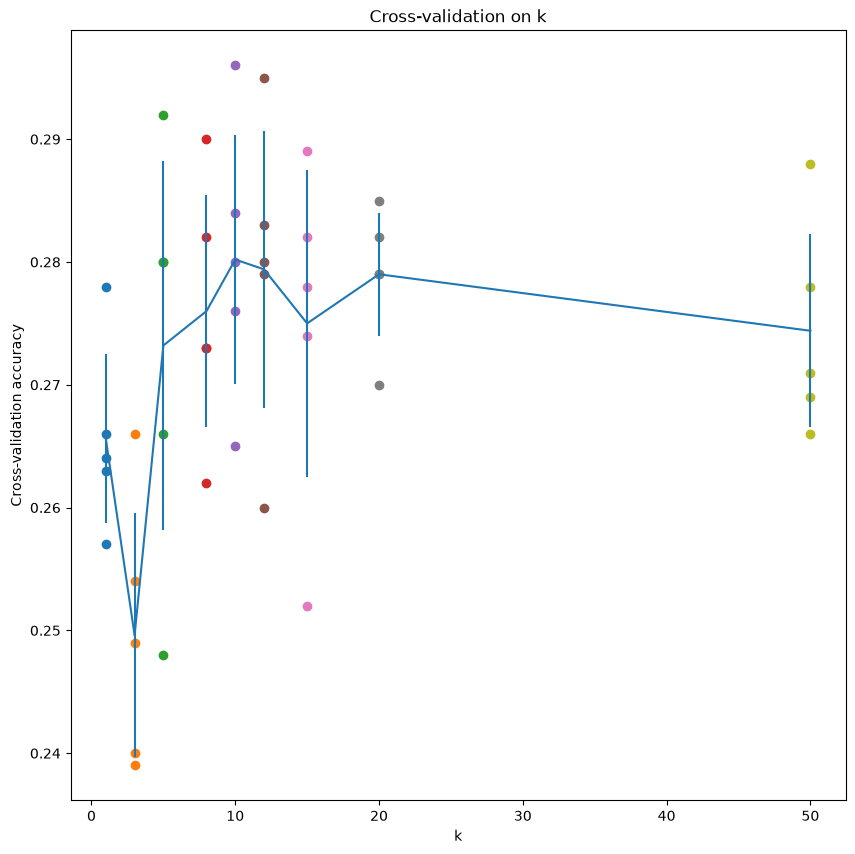

In [23]:
# plot the raw observations
for k in k_choices:
    accuracies = k_to_accuracies[k]
    plt.scatter([k] * len(accuracies), accuracies)

# plot the trend line with error bars that correspond to standard deviation
accuracies_mean = np.array([np.mean(v) for k, v in sorted(k_to_accuracies.items())])
accuracies_std = np.array([np.std(v) for k, v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.title("Cross-validation on k")
plt.xlabel("k")
plt.ylabel("Cross-validation accuracy")
plt.show()

Here's our best performing k

In [26]:
best_k = 10

# Use entire dataset instead of sub sampling
X_train, y_train, X_test, y_test = load_cifar10("data/cifar10/cifar-10-batches-py")

X_train = X_train.astype(np.float64)
X_test = X_test.astype(np.float64)

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

# Compute and display the accuracy
num_correct = np.sum(y_test_pred == y_test)
num_test = X_test.shape[0]
accuracy = float(num_correct) / num_test
print("Got %d / %d correct => accuracy: %f" % (int(num_correct), num_test, accuracy))

Got 3386 / 10000 correct => accuracy: 0.338600


### Comparison to MNIST and Fashion MNIST

The best k that was found allowed the model to get an accuracy score of 33.86% which isn't very good.

KNN classification of CIFAR10 is quite difficult because they are low-res color images that have very high intra-class and inter-class variability. We weren't expecting the KNN classifier to do very well on this dataset.

These experiments have taught us that KNN classification without feature extraction works well on relatively simple datasets that only use one color channel.

## Feature extraction to improve Fashion MNIST

We chose **Local Binary Patterns (LBP)** rather than a projection histogram.

LBP encodes, for every pixel, how it compares to its 8 neighbours (brighter/darker), which captures local *texture* (edges, corners, flat areas). This is a good fit for Fashion MNIST because several classes are mostly distinguished by texture and local shape (e.g. the ribbing of a pullover vs. the smooth surface of a bag or the straps of a sandal).

In [29]:
X_train, y_train = load_mnist("data/fashion", kind="train")
X_test, y_test = load_mnist("data/fashion", kind="t10k")

X_train = X_train.astype(np.float64)
X_test = X_test.astype(np.float64)

In [46]:
def compute_lbp(images):
    """LBP code (0-255) for every pixel, using 8 neighbors (radius 1)."""
    N, H, W = images.shape
    padded = np.pad(images, ((0, 0), (1, 1), (1, 1)), mode="edge")
    center = padded[:, 1:-1, 1:-1]
    offsets = [(-1, -1), (-1, 0), (-1, 1), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1)]

    lbp = np.zeros((N, H, W), dtype=np.uint8)
    for bit, (dy, dx) in enumerate(offsets):
        neighbor = padded[:, 1 + dy : 1 + dy + H, 1 + dx : 1 + dx + W]
        lbp |= ((neighbor >= center).astype(np.uint8)) << bit
    return lbp


def lbp_cell_histograms(X, image_shape=(28, 28), cell_size=7, n_bins=256):
    """
    Full LBP pipeline with cells, skipping the "normalize each histogram" step:
    - compute per-pixel LBP codes
    - divide the image into non-overlapping cell_size x cell_size cells
    - compute a raw-count histogram of codes per cell
    - concatenate all cell histograms into one feature vector
    """
    N = X.shape[0]
    H, W = image_shape
    images = X.reshape(N, H, W)
    lbp = compute_lbp(images)

    n_cells_h = H // cell_size
    n_cells_w = W // cell_size
    n_cells = n_cells_h * n_cells_w

    features = np.zeros((N, n_cells * n_bins))

    cell_idx = 0
    for i in range(n_cells_h):
        for j in range(n_cells_w):
            cell = lbp[:, i * cell_size:(i + 1) * cell_size, j * cell_size:(j + 1) * cell_size]
            cell_flat = cell.reshape(N, -1)
            for n in range(N):
                features[n, cell_idx * n_bins:(cell_idx + 1) * n_bins] = np.bincount(
                    cell_flat[n], minlength=n_bins
                )
            cell_idx += 1

    return features

Visualisation of LBP

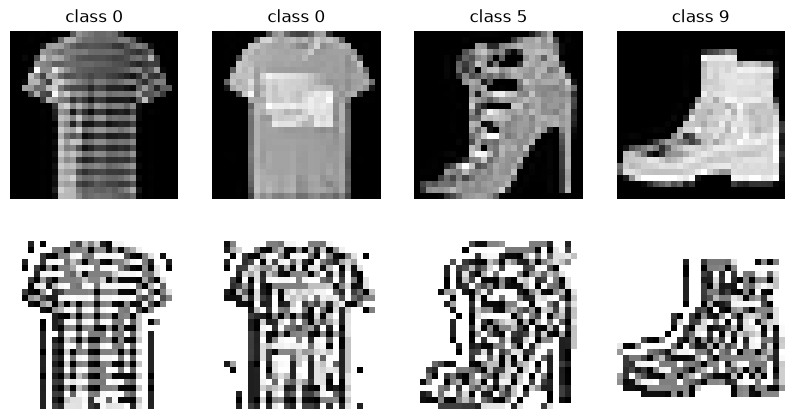

In [47]:
sample_idxs = np.random.choice(X_train.shape[0], 4, replace=False)
sample_images = X_train[sample_idxs].reshape(-1, 28, 28)
sample_lbp = compute_lbp(sample_images)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i in range(4):
    axes[0, i].imshow(sample_images[i], cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(f"class {int(y_train[sample_idxs[i]])}")
    axes[1, i].imshow(sample_lbp[i], cmap="gray")
    axes[1, i].axis("off")
plt.show()

In [48]:
# Sub-sampling
num_training = 5000
mask = range(num_training)
X_train = X_train[mask].astype(np.float64)
y_train = y_train[mask]

num_test = 500
mask = range(num_test)
X_test = X_test[mask].astype(np.float64)
y_test = y_test[mask]

# Extract LBP histogram features instead of using raw pixels
X_train_lbp = lbp_cell_histograms(X_train)
X_test_lbp = lbp_cell_histograms(X_test)

print("LBP feature shape:", X_train_lbp.shape)

LBP feature shape: (5000, 4096)


### Cross-validation

In [49]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50]

X_train_folds = []
y_train_folds = []

X_train_folds = np.array_split(X_train_lbp, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

k_to_accuracies = {}

for k in k_choices:
    k_to_accuracies[k] = []
    for f in range(num_folds):
        # Build training data: all folds except fold f
        X_train_cv = np.concatenate(X_train_folds[:f] + X_train_folds[f + 1 :])
        y_train_cv = np.concatenate(y_train_folds[:f] + y_train_folds[f + 1 :])

        # Validation data: fold f
        X_valid_cv = X_train_folds[f]
        y_valid_cv = y_train_folds[f]

        # Train a fresh classifier on the 4 folds
        classifier_cv = KNearestNeighbor()
        classifier_cv.train(X_train_cv, y_train_cv)

        # Predict on the held-out fold
        dists_cv = classifier_cv.compute_distances_no_loops(X_valid_cv)
        y_valid_pred = classifier_cv.predict_labels(dists_cv, k=k)

        num_correct = np.sum(y_valid_pred == y_valid_cv)
        accuracy = float(num_correct) / X_valid_cv.shape[0]
        k_to_accuracies[k].append(accuracy)

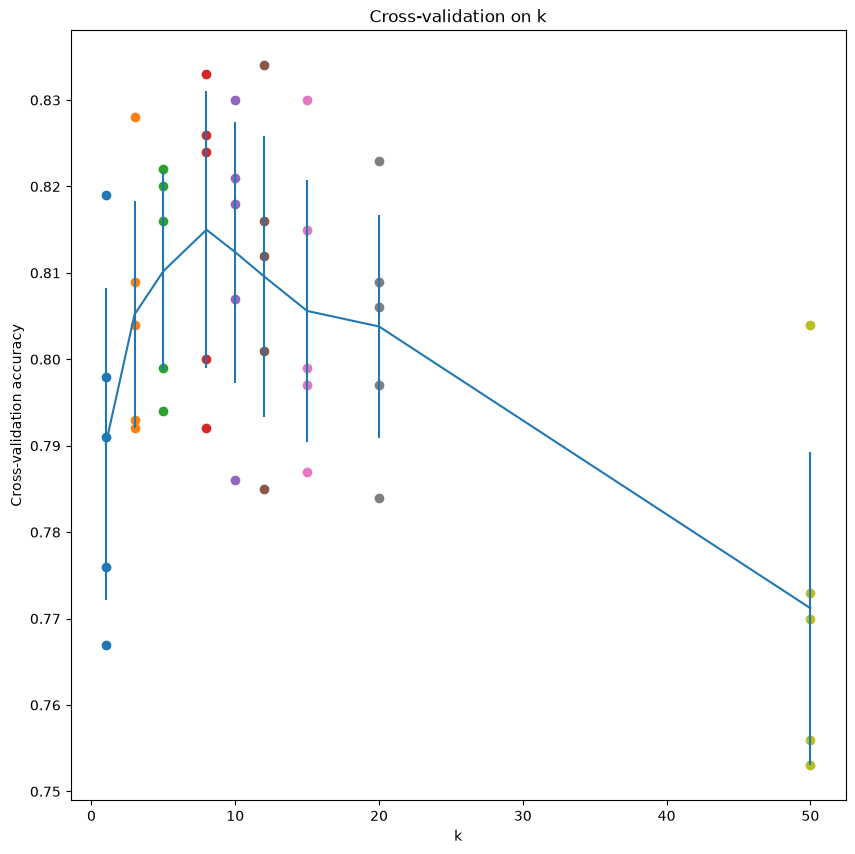

In [50]:
# plot the raw observations
for k in k_choices:
    accuracies = k_to_accuracies[k]
    plt.scatter([k] * len(accuracies), accuracies)

# plot the trend line with error bars that correspond to standard deviation
accuracies_mean = np.array([np.mean(v) for k, v in sorted(k_to_accuracies.items())])
accuracies_std = np.array([np.std(v) for k, v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.title("Cross-validation on k")
plt.xlabel("k")
plt.ylabel("Cross-validation accuracy")
plt.show()

In [54]:
best_k_lbp = 8

X_train, y_train = load_mnist("data/fashion", kind="train")
X_test, y_test = load_mnist("data/fashion", kind="t10k")

X_train = X_train.astype(np.float64)
X_test = X_test.astype(np.float64)

X_train_lbp = lbp_cell_histograms(X_train.astype(np.float64))
X_test_lbp = lbp_cell_histograms(X_test.astype(np.float64))

classifier = KNearestNeighbor()
classifier.train(X_train_lbp, y_train)
y_test_pred = classifier.predict(X_test_lbp, k=best_k_lbp)

num_correct = np.sum(y_test_pred == y_test)
num_test = X_test_lbp.shape[0]
accuracy = float(num_correct) / num_test
print("Got %d / %d correct => accuracy: %f" % (int(num_correct), num_test, accuracy))

Got 8629 / 10000 correct => accuracy: 0.862900


### Comparison to Fashion MNIST without feature extraction

We got an accuracy of 86.29% which feature extraction and 85.54% without it. That's not a large enough increase to make using FE justifiable in this situation.